# 2. 합성곱 신경망 Convolutional Neural Network

## 2-1. 흑백 이미지의 분류
* ANN에서 진행한 작업을 다시 진행해보고 결과를 비교하자.

In [1]:
from keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


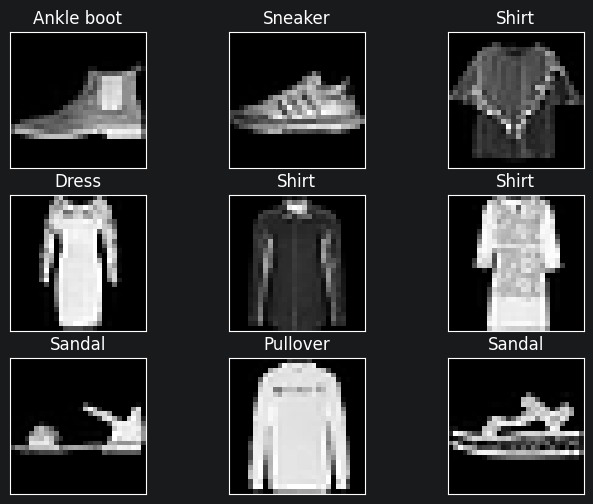

In [2]:
# 이미지 확인
import matplotlib.pyplot as plt
import numpy as np

class_names = ['T-shirt/top', 'Trouser', 'Pullover',
               'Dress', 'Coat', 'Sandal', 'Shirt',
               'Sneaker', 'Bag', 'Ankle boot']
samples = np.random.randint(len(x_train), size=9)

plt.figure(figsize=(8,6))
for i, idx in enumerate(samples):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx], cmap = 'gray')
    plt.title(class_names[y_train[idx]])

plt.show()

In [3]:
# 검증 데아터 준비
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,# trains set에서 다시 valid set을 나눔
                                                  test_size=0.3,
                                                  random_state=42)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(42000, 28, 28) (42000,)
(18000, 28, 28) (18000,)


In [4]:
# 이미지 데이터 정규화
## 각 픽셀값이 0-255의 천차만별 => 가중치 폭주하거나 기울기에 영향을 줄 수 있음

x_train = x_train.astype('float32')/255.
x_val = x_val.astype('float32')/255.
x_test = x_test.astype('float32')/255.

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(42000, 28, 28) (42000,)
(18000, 28, 28) (18000,)
(10000, 28, 28) (10000,)


In [5]:
# 데이터 shape 확인
## ANN 때와는 데이터의 모양이 다르다
print('x_train :', x_train.shape)
print('x_val :', x_val.shape)
print('x_test :', x_test.shape)

x_train : (42000, 28, 28)
x_val : (18000, 28, 28)
x_test : (10000, 28, 28)


In [6]:
import keras
print(keras.backend.image_data_format())

channels_last


In [7]:
# 채널 축 추가
## tensorflow를 쓰지 않고 차원을 바꿔버리자. 채널 축을 쓰기 위함
x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print('x_train :', x_train.shape)
print('x_val :', x_val.shape)
print('x_test :', x_test.shape)

x_train : (42000, 28, 28, 1)
x_val : (18000, 28, 28, 1)
x_test : (10000, 28, 28, 1)


In [7]:
# # gemini가 pytorch 기준으로 알려줘서 바로 위 블록에서 모양 잘못 지정함. 그래서 재지정.
# # 다음에 쓸 일 있으면 잘 알아보고 지정하거라~
# x_train = x_train.transpose(0, 2, 3, 1)
# x_val = x_val.transpose(0, 2, 3, 1)
# x_test = x_test.transpose(0, 2, 3, 1)
#
# print('x_train :', x_train.shape)
# print('x_val :', x_val.shape)
# print('x_test :', x_test.shape)

x_train : (42000, 28, 1, 28)
x_val : (18000, 28, 28, 1)
x_test : (10000, 28, 28, 1)


In [8]:
# 모델 만들기
from keras import layers

def build_model():
    model = keras.Sequential()
    model.add(layers.InputLayer(shape=(28, 28, 1)))
    model.add(layers.Conv2D(filters=16, kernel_size=3, padding='same', strides=(1,1), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(layers.Conv2D(filters=32, kernel_size=3, padding='same', strides=(1,1), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(layers.Conv2D(filters=64, kernel_size=3, padding='same', strides=(1,1), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    return model

In [9]:
import keras
model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,874 (237.79 KB)

 Trainable params: 60,874 (237.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# model compile
import keras
adam = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
# one-hot encoding
# 손실함수로 categorical_crossentropy를 사용할 거면 One-hot encoding 필요
from keras.utils import to_categorical

y_train_1h = to_categorical(y_train)
y_val_1h = to_categorical(y_val)
y_test_1h = to_categorical(y_test)

print(y_train_1h.shape)
print(y_train_1h[:5])

(42000, 10)
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


In [12]:
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(x_train, y_train_1h,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(x_val, y_val_1h),
                    verbose=1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.7907 - loss: 0.5812 - val_accuracy: 0.8606 - val_loss: 0.3923
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8697 - loss: 0.3629 - val_accuracy: 0.8791 - val_loss: 0.3324
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8869 - loss: 0.3146 - val_accuracy: 0.8881 - val_loss: 0.3012
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8983 - loss: 0.2836 - val_accuracy: 0.8872 - val_loss: 0.3146
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9035 - loss: 0.2618 - val_accuracy: 0.9028 - val_loss: 0.2702
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9112 - loss: 0.2419 - val_accuracy: 0.9039 - val_loss: 0.2616
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9166 - loss: 0.2274 - val_accuracy: 0.9097 - val_loss: 0.2514
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9238 - loss: 0.2108 - 

In [13]:
# 학습 곡선
import matplotlib.pyplot as plt
import pandas as pd

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss') #loss와 val_loss 변수는 keras가 알아서 만들어준다
    plt.plot(hist['epoch'], hist['val_loss'],label = 'Val Loss') #loss와 val_loss 변수는 keras가 알아서 만들어준다
    plt.legend()

    plt.subplot(1,2,2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')
    plt.legend()
    plt.show()

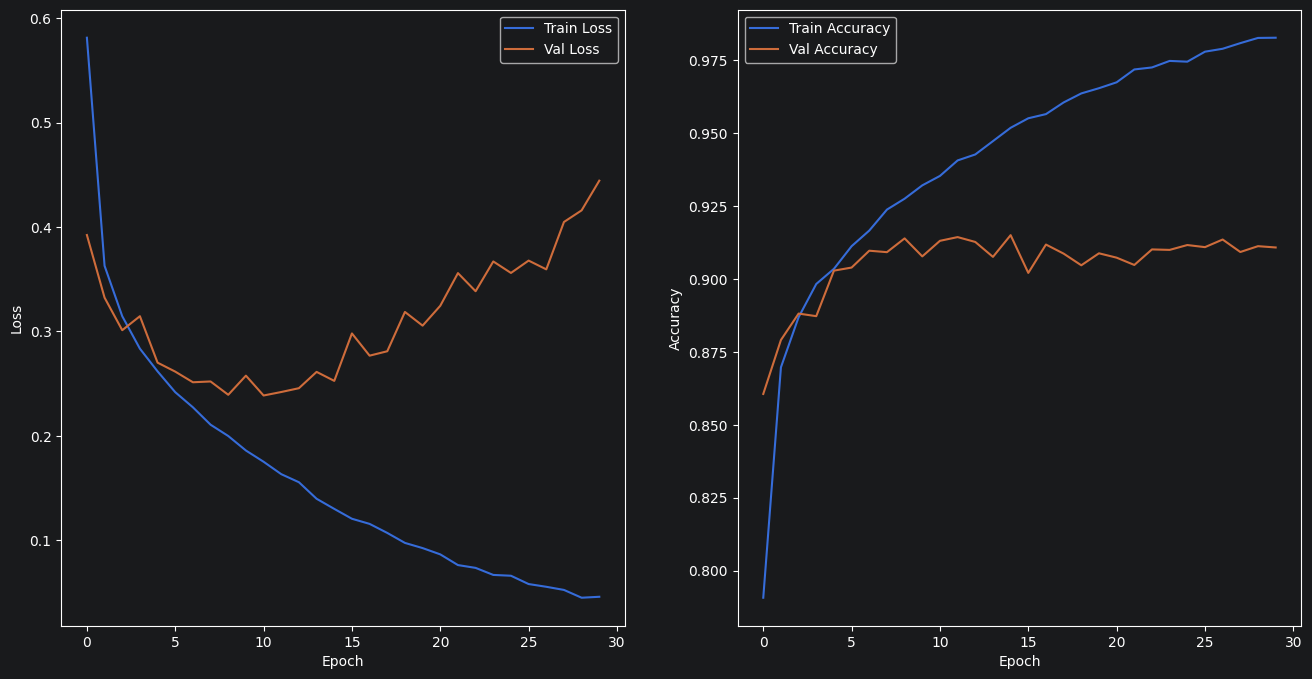

In [14]:
plot_history(history)

## 2-2. Dropout
* overfitting을 수정하기 위해 dropout 레이어를 추가한 모델을 학습시킨다.

In [15]:
import keras
from keras import layers

def build_dropout_model() :
    model = keras.Sequential()

    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(filters=16, kernel_size=3, padding='same', strides=(1,1), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(layers.Dropout(rate=0.2))

    model.add(layers.Conv2D(filters=32, kernel_size=3, padding='same', strides=(1,1), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(layers.Dropout(rate=0.2))

    model.add(layers.Conv2D(filters=64, kernel_size=3, padding='same', strides=(1,1), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(layers.Dropout(rate=0.2))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

In [16]:
model = build_dropout_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,874 (237.79 KB)

 Trainable params: 60,874 (237.79 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
# learning
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(x_train, y_train_1h,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(x_val, y_val_1h),
                    verbose=1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7335 - loss: 0.7220 - val_accuracy: 0.8276 - val_loss: 0.4646
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.8301 - loss: 0.4618 - val_accuracy: 0.8615 - val_loss: 0.3822
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8506 - loss: 0.4088 - val_accuracy: 0.8688 - val_loss: 0.3567
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.8630 - loss: 0.3731 - val_accuracy: 0.8782 - val_loss: 0.3313
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8699 - loss: 0.3539 - val_accuracy: 0.8928 - val_loss: 0.2958
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8799 - loss: 0.3258 - val_accuracy: 0.8949 - val_loss: 0.2860
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8831 - loss: 0.3157 - val_accuracy: 0.9006 - val_loss: 0.2753
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8899 - loss: 0.2989 - 

In [20]:
# 1. 입력 데이터와 정답 데이터의 개수가 일치하는가?
print(f"x_train 모양: {x_train.shape}")  # (N, 28, 28, 1) 형태여야 함
print(f"y_train_1h 모양: {y_train_1h.shape}") # (N, 10) 형태여야 함

# 2. 검증 데이터도 마찬가지
print(f"x_val 모양: {x_val.shape}")
print(f"y_val_1h 모양: {y_val_1h.shape}")

x_train 모양: (42000, 28, 28, 1)
y_train_1h 모양: (42000, 10)
x_val 모양: (18000, 28, 28, 1)
y_val_1h 모양: (18000, 10)


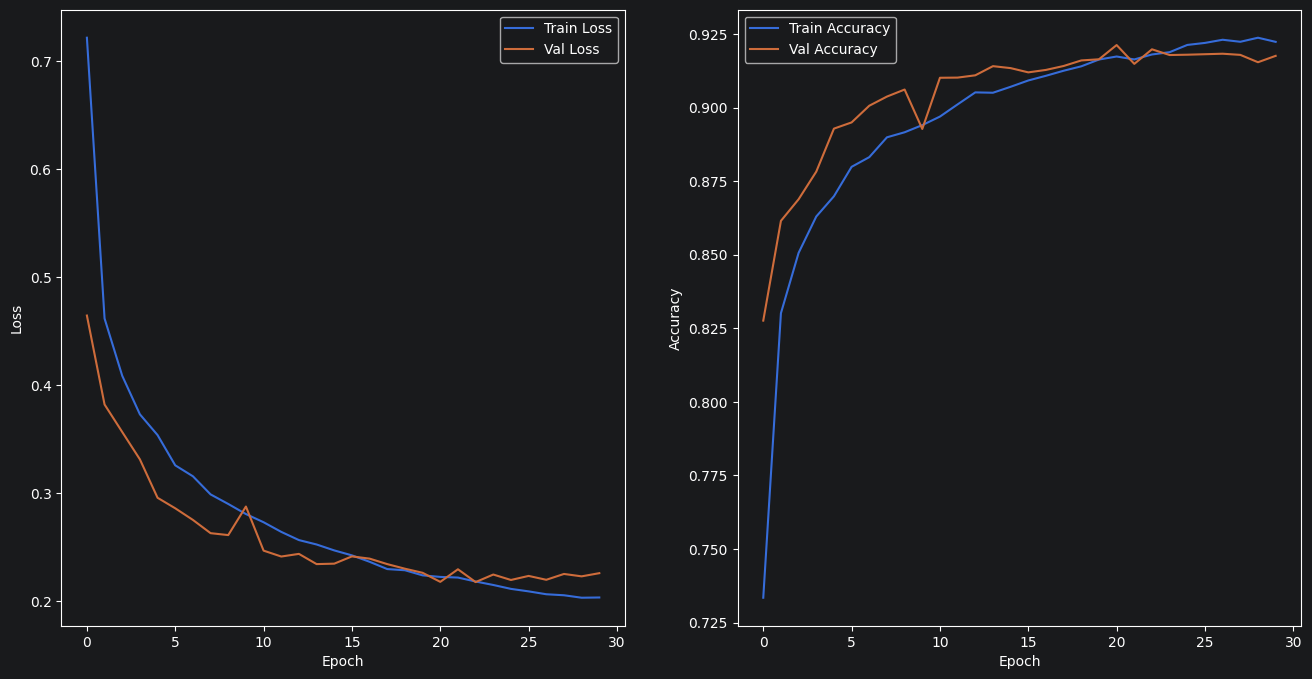

In [21]:
# 학습 곡선
plot_history(history)

In [22]:
# 예측
y_pred = model.predict(x_test)
y_pred_argmax = np.argmax(y_pred, axis=1)

y_pred_argmax[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [23]:
# 평가 지표
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def print_score(y_test, y_pred):
    print('accuracy: %.3f' % (accuracy_score(y_test, y_pred)))
    print('precision: %.3f' % (precision_score(y_test, y_pred, average='macro')))
    print('recall_score: %.3f' % (recall_score(y_test, y_pred, average='macro')))
    print('f1_score: %.3f' % (f1_score(y_test, y_pred, average='macro')))

In [24]:
print_score(y_test, y_pred_argmax)

accuracy: 0.911
precision: 0.911
recall_score: 0.911
f1_score: 0.910


## 2-3. 다중분류
* 1,2번과 같은 작업 진행. 단, one-hot encoding을 이용한 labeling을 하지 않고 진행.

In [25]:
model = build_dropout_model()

In [26]:
# compile. loss 함수만 다르게 지정
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [27]:
# learning
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(x_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(x_val, y_val),
                    verbose=1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7268 - loss: 0.7256 - val_accuracy: 0.8341 - val_loss: 0.4642
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8315 - loss: 0.4598 - val_accuracy: 0.8525 - val_loss: 0.4031
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8515 - loss: 0.4015 - val_accuracy: 0.8806 - val_loss: 0.3292
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8654 - loss: 0.3657 - val_accuracy: 0.8849 - val_loss: 0.3156
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8723 - loss: 0.3429 - val_accuracy: 0.8887 - val_loss: 0.3022
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8815 - loss: 0.3220 - val_accuracy: 0.8952 - val_loss: 0.2846
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8856 - loss: 0.3067 - val_accuracy: 0.9033 - val_loss: 0.2618
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8899 - loss: 0.2937 - 

In [29]:
# 예측
y_pred = model.predict(x_test)

y_pred[:1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[5.3100533e-09, 2.0986993e-10, 6.7800912e-09, 1.6129158e-08,
        2.1103261e-08, 3.2070529e-05, 1.0756700e-08, 1.6876284e-04,
        9.9237223e-09, 9.9979919e-01]], dtype=float32)

In [30]:
# 평가지표 계산
y_pred_argmax = np.argmax(y_pred, axis=1)
print_score(y_test, y_pred_argmax)

accuracy: 0.918
precision: 0.919
recall_score: 0.918
f1_score: 0.918
